<a href="https://colab.research.google.com/github/jaclynclark3/Public/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%pip -q install psycopg2-binary

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 28.6 MB/s eta 0:00:00


In [6]:
try:
    conn = psycopg2.connect(
        host=userdata.get("DB_HOST"), port=5432,
        dbname=userdata.get("DB_NAME"), user=userdata.get("DB_USER"),
        password=userdata.get("DB_PASSWORD"),
        sslmode="require", connect_timeout=10)
except psycopg2.Error:
    raise RuntimeError("Check DB Secrets and database availability privately.") from None
cur = conn.cursor()
print("Connected.")

Connected.


In [8]:
cur.execute("INSERT INTO public.name (fips, name) VALUES ('51999', 'Practice County');")
conn.commit()
cur.execute("SELECT fips, name FROM public.name WHERE fips = '51999';")
print(cur.fetchall())

InFailedSqlTransaction: current transaction is aborted, commands ignored until end of transaction block


In [10]:
conn.rollback() # Rollback any previous failed transaction
cur.execute("UPDATE public.name SET name = 'Practice County - Updated' WHERE fips = '51999';")
conn.commit()
cur.execute("SELECT fips, name FROM public.name WHERE fips = '51999';")
print(cur.fetchall())

[('51999', 'Practice County - Updated')]


## Q0

In [11]:
sql_q0 = """

SELECT n.fips, n.name, p.year, p.population
FROM public.name AS n
INNER JOIN public.population AS p
  ON n.fips = p.fips
WHERE n.fips LIKE '51%' AND p.year = 2024
ORDER BY p.population DESC, n.fips;

"""

### q0 data


In [12]:
cur.execute(sql_q0)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
q0 = pd.DataFrame(rows, columns=columns)
display(q0)

,fips,name,year,population
0,51059,Fairfax County,2024,1160925
1,51153,Prince William County,2024,497003
2,51810,Virginia Beach city,2024,454808
3,51107,Loudoun County,2024,443380
4,51041,Chesterfield County,2024,389793
5,51087,Henrico County,2024,338696
6,51550,Chesapeake city,2024,254997
7,51013,Arlington County,2024,239807
8,51760,Richmond city,2024,233655
9,51710,Norfolk city,2024,231105


### q0 chart

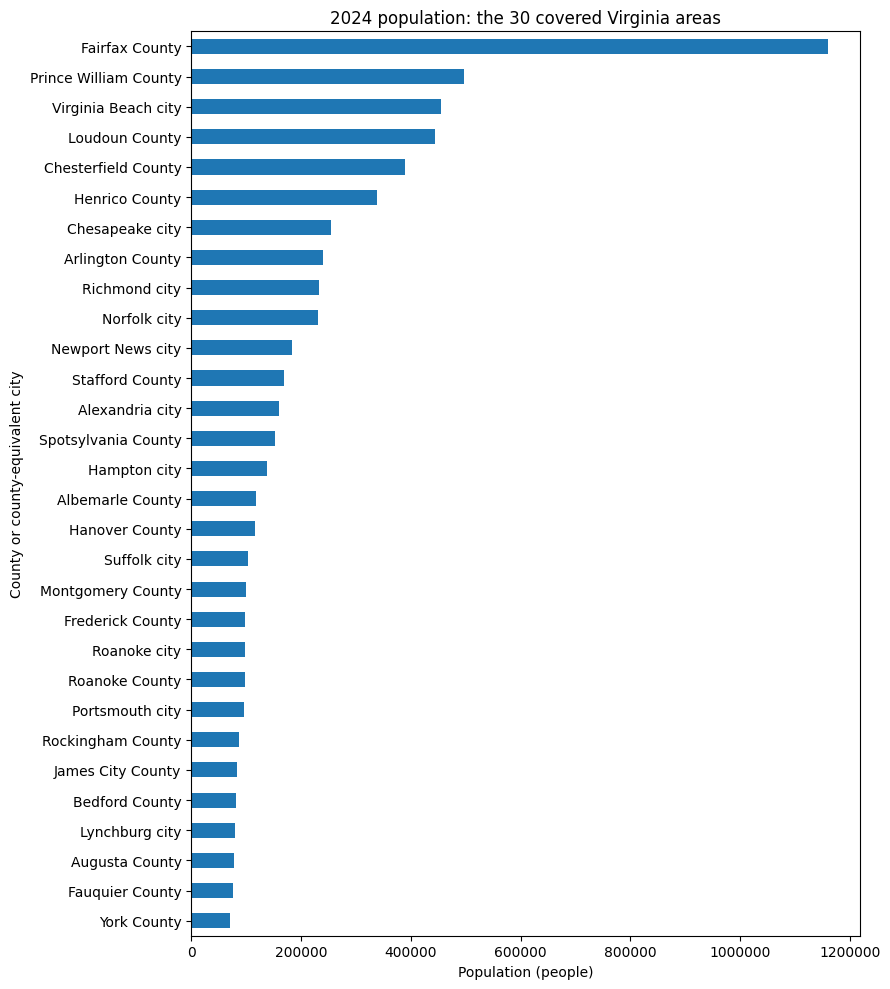

In [13]:
plot_q0 = q0.sort_values(["population", "fips"])
ax = plot_q0.plot.barh(x="name", y="population", legend=False, figsize=(9, 10))
ax.set_title("2024 population: the 30 covered Virginia areas")
ax.set_xlabel("Population (people)")
ax.set_ylabel("County or county-equivalent city")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

## Population Growth Rate for Fauquier County

In [14]:
sql_q1 = """
SELECT p.fips, p.year, p.population
FROM public.population AS p
WHERE p.fips = '51061' AND p.year BETWEEN 2014 AND 2024
ORDER BY p.year ASC;
"""

cur.execute(sql_q1)
rows = cur.fetchall()
columns = [col[0] for col in cur.description]
population_data = pd.DataFrame(rows, columns=columns)

# Calculate previous year's population and current year's population
population_data['previous_value'] = population_data['population'].shift(1)
population_data['current_value'] = population_data['population']

# Filter for years 2015-2024 for growth rate calculation
growth_rate_data = population_data[population_data['year'] >= 2015].copy()

# Calculate growth rate
growth_rate_data['growth_rate'] = (growth_rate_data['current_value'] - growth_rate_data['previous_value']) / growth_rate_data['previous_value']

# Select and reorder columns as requested
result_df = growth_rate_data[['fips', 'year', 'previous_value', 'current_value', 'growth_rate']]

display(result_df)

,fips,year,previous_value,current_value,growth_rate
0,51061,2015,NaN,68782,NaN
1,51061,2016,68782.0,69069,0.004173
2,51061,2017,69069.0,69465,0.005733
3,51061,2018,69465.0,70675,0.017419
4,51061,2019,70675.0,71222,0.007740
5,51061,2021,71222.0,73815,0.036407
6,51061,2022,73815.0,74664,0.011502
7,51061,2023,74664.0,75165,0.006710
8,51061,2024,75165.0,75865,0.009313


In [15]:
q3 = """
SELECT
  "p15"."year" AS "baseline_year",
  "p15"."population" AS "population_2015",
  "p_curr"."year" AS "comparison_year",
  "p_curr"."population" AS "comparison_population",
  ("p_curr"."population" - "p15"."population") AS "population_change",
  (
    ("p_curr"."population" - "p15"."population")::double precision
    / "p15"."population"::double precision
  ) * 100.0 AS "percent_change_from_2015"
FROM
  "name" AS "n"
JOIN
  "population" AS "p15"
ON
  "n"."fips" = "p15"."fips"
JOIN
  "population" AS "p_curr"
ON
  "n"."fips" = "p_curr"."fips"
WHERE
  "n"."name" = 'Fauquier County'
  AND "p15"."year" = 2015
  AND "p_curr"."year" BETWEEN 2015 AND 2024
ORDER BY
  "p_curr"."year" ASC
NULLS LAST;
"""

# Ensure 'cur' is defined by running the database connection cell (e.g., cell 'jirPS0JpeCj2') first.
cur.execute(q3)
rows = cur.fetchall()

for row in rows:
    print(row)

(2015, 68782, 2015, 68782, 0, 0.0)
(2015, 68782, 2016, 69069, 287, 0.4172603297374313)
(2015, 68782, 2017, 69465, 683, 0.9929923526504026)
(2015, 68782, 2018, 70675, 1893, 2.7521735337733713)
(2015, 68782, 2019, 71222, 2440, 3.5474397371405306)
(2015, 68782, 2021, 73815, 5033, 7.31732139222471)
(2015, 68782, 2022, 74664, 5882, 8.551655956500246)
(2015, 68782, 2023, 75165, 6383, 9.28004419760984)
(2015, 68782, 2024, 75865, 7083, 10.297752318920649)


Q1 Visual:

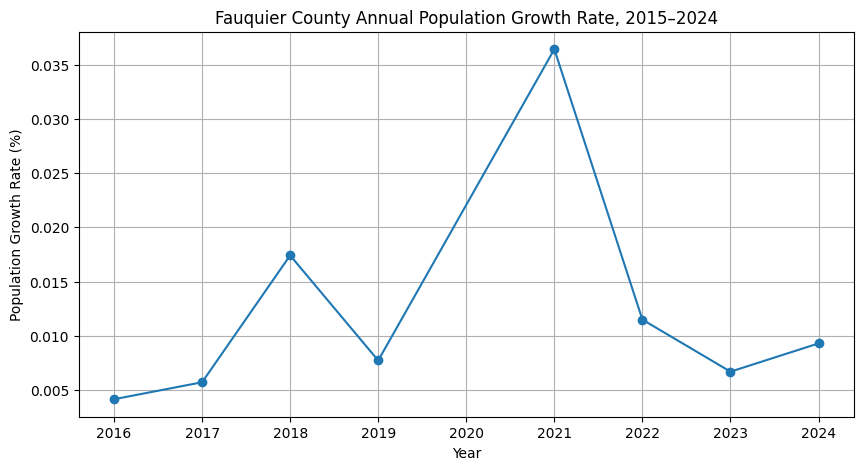

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    growth_rate_data["year"],
    growth_rate_data["growth_rate"],
    marker="o"
)

plt.title("Fauquier County Annual Population Growth Rate, 2015–2024")
plt.xlabel("Year")
plt.ylabel("Population Growth Rate (%)")
plt.grid(True)
plt.show()

Q1 Interpertation:
Fauquier County’s annual population growth rate fluctuated from 2016–2024, with the highest growth occurring in 2021 at about 3.7%. Growth slowed sharply after 2021, reaching its lowest point in 2023 at about 0.7%, before increasing slightly to about 0.9% in 2024.




Q3: Visualize and answeer your own question


In [23]:
# Store your tested SQL query in sql_q3
sql_q3 = """
WITH CountyPopulation AS (
    SELECT
        p.year,
        p.population,
        LAG(p.population, 1) OVER (ORDER BY p.year) AS previous_population
    FROM public.population AS p
    JOIN public.name AS n ON p.fips = n.fips
    WHERE n.name = 'Fauquier County'
),
AnnualGrowth AS (
    SELECT
        year,
        (population - previous_population)::double precision / previous_population::double precision AS population_growth_rate
    FROM CountyPopulation
    WHERE previous_population IS NOT NULL
)
SELECT
    year,
    population_growth_rate
FROM AnnualGrowth
WHERE population_growth_rate > 0.01
ORDER BY year;
"""

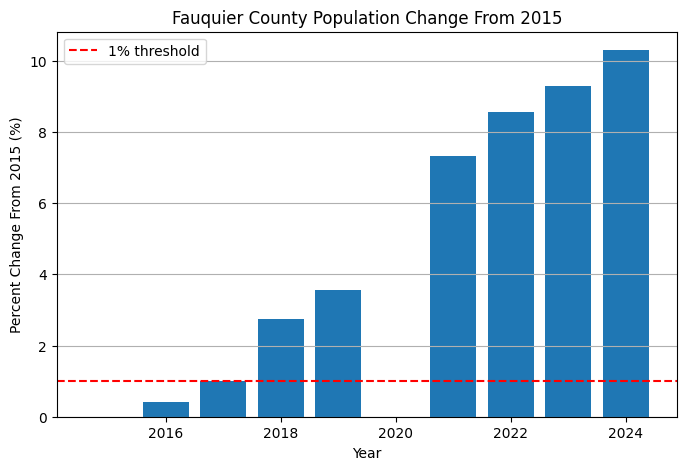

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame from the results of the q3 SQL query.
# 'rows' and 'cur.description' are available from the execution of cell HaguMHT7Y5F4.
columns_q3 = [desc[0] for desc in cur.description] # Get column names from cursor description
q3_df = pd.DataFrame(rows, columns=columns_q3)

plt.figure(figsize=(8, 5))
# Plot 'comparison_year' against 'percent_change_from_2015'
plt.bar(q3_df["comparison_year"], q3_df["percent_change_from_2015"])

plt.title("Fauquier County Population Change From 2015") # Adjusted title
plt.xlabel("Year")
plt.ylabel("Percent Change From 2015 (%)") # Adjusted label
plt.axhline(1.0, linestyle="--", color="red", label="1% threshold") # 1% for percentage data
plt.legend()
plt.grid(axis='y') # Add grid for readability
plt.show()

Q3: Interpertation
Fauquier County’s annual population growth rate exceeded 1% in 2018, 2021, and 2022. The highest growth among these years occurred in 2021, at approximately 3.7%.

Final Summary: I completed Q1, Q2, and Q3 for Fauquier County and created a visualization for each question. I worked through the lab on my own time, using the data that was provided and checking that the tables, charts, and interpretations matched the available results. The visualizations helped show the population trends and made it easier to identify changes from year to year rather than relying only on the raw numbers. For example, the Q1 visualization showed how Fauquier County’s population growth rate changed across the years, including the noticeable increase in 2021 followed by slower growth in 2022–2024. For Q3, the visualization made it easier to identify which years passed the 1% population-growth threshold. The original nominal median household income approach would no longer work correctly with the data available to me, so I completed the lab using the variables and information that were actually provided rather than trying to force a calculation that the dataset could not support. Gemini was helpful when creating the visualizations, especially for turning the DataFrames into readable charts with appropriate titles, axis labels, and formatting. I reviewed the visualization code before using it and hit “Accept & Run” after checking that it matched my Fauquier County data, so the visualization code shown in the lab should receive credit as Gemini-generated/assisted code rather than being presented as entirely my own code.